In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar100
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow_datasets as tfds

# Для воспроизводимости
tf.random.set_seed(42)
np.random.seed(42)

In [13]:
def circular_mask(size):
    """Круглая маска диаметром size (ожидается нечётное значение)."""
    center = size // 2
    radius = size // 2
    Y, X = np.ogrid[:size, :size]
    dist = np.sqrt((X - center)**2 + (Y - center)**2)
    return (dist <= radius).astype(np.float32)

def cross_mask(size):
    """Крестообразная маска: центральная строка и столбец.
       Для чётных размеров добавляются две центральные линии."""
    mask = np.zeros((size, size), dtype=np.float32)
    if size % 2 == 1:
        c = size // 2
        mask[c, :] = 1
        mask[:, c] = 1
    else:
        c1 = size // 2 - 1
        c2 = size // 2
        mask[c1, :] = 1
        mask[c2, :] = 1
        mask[:, c1] = 1
        mask[:, c2] = 1
    return mask

def checkerboard_mask(size):
    """Разреженная квадратная маска с шахматным узором."""
    mask = np.zeros((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            if (i + j) % 2 == 0:
                mask[i, j] = 1
    return mask

def full_mask(size):
    """Стандартная маска – все единицы (обычный фильтр)."""
    return np.ones((size, size), dtype=np.float32)

In [14]:
class MaskedConv2D(layers.Layer):
    def __init__(self, filters, kernel_size, mask,
                 strides=(1,1), padding='same', use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.strides = strides
        self.padding = padding
        self.use_bias = use_bias
        self.mask = tf.constant(mask, dtype=tf.float32)
        self.mask = tf.reshape(self.mask, (self.mask.shape[0], self.mask.shape[1], 1, 1))

    def build(self, input_shape):
        in_channels = input_shape[-1]
        kernel_shape = self.kernel_size + (in_channels, self.filters)
        self.kernel = self.add_weight(name='kernel', shape=kernel_shape,
                                      initializer='glorot_uniform', trainable=True)
        if self.use_bias:
            self.bias = self.add_weight(name='bias', shape=(self.filters,),
                                        initializer='zeros', trainable=True)
        else:
            self.bias = None
        self.mask = tf.tile(self.mask, [1, 1, in_channels, self.filters])

    def call(self, inputs):
        masked_kernel = self.kernel * self.mask
        outputs = tf.nn.conv2d(inputs, masked_kernel,
                               strides=[1, self.strides[0], self.strides[1], 1],
                               padding=self.padding.upper())
        if self.use_bias:
            outputs = tf.nn.bias_add(outputs, self.bias)
        return outputs

In [15]:
def build_model(input_shape, mask, kernel_size, num_classes=10, filters=32, depth=1):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    
    # Первый свёрточный слой
    model.add(MaskedConv2D(filters, kernel_size, mask, padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # Второй свёрточный слой (если depth=2)
    if depth == 2:
        model.add(MaskedConv2D(filters*2, kernel_size, mask, padding='same'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

In [17]:
def load_dataset(name):
    if name == 'mnist':
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        input_shape = (28, 28, 1)
        num_classes = 10
    elif name == 'fashion_mnist':
        (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
        input_shape = (28, 28, 1)
        num_classes = 10
    else:
        raise ValueError("Unknown dataset")

    # Нормализация для MNIST и Fashion-MNIST
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0

    if len(x_train.shape) == 3:
        x_train = np.expand_dims(x_train, axis=-1)
        x_test = np.expand_dims(x_test, axis=-1)

    y_train = tf.keras.utils.to_categorical(y_train, num_classes)
    y_test = tf.keras.utils.to_categorical(y_test, num_classes)

    return x_train, y_train, x_test, y_test, input_shape, num_classes

In [18]:
experiments = {
    'full': {
        'sizes': [3, 5],
        'mask_fn': full_mask
    },
    'circle': {
        'sizes': [5, 6],
        'mask_fn': circular_mask
    },
    'cross': {
        'sizes': [2, 3, 4, 5],
        'mask_fn': cross_mask
    },
    'checkerboard': {
        'sizes': [2, 4, 6],
        'mask_fn': checkerboard_mask
    }
}


Запуск на датасете: MNIST

--- full, размер 3x3 ---


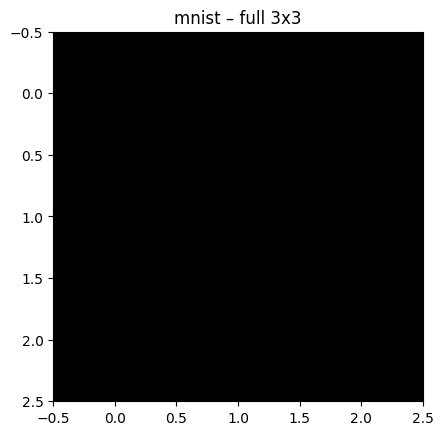


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8893 - loss: 0.3930 - val_accuracy: 0.9545 - val_loss: 0.1543
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9538 - loss: 0.1540 - val_accuracy: 0.9692 - val_loss: 0.1066
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9670 - loss: 0.1094 - val_accuracy: 0.9722 - val_loss: 0.0875
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9743 - loss: 0.0850 - val_accuracy: 0.9753 - val_loss: 0.0772
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9799 - loss: 0.0693 - val_accuracy: 0.9778 - val_loss: 0.0714
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9835 - loss: 0.0579 - val_accuracy: 0.9803 - val_loss: 0.0675
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9863 - loss: 0.0490 - val_accuracy: 0.9808 - val_loss: 0.0646
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9884 - loss: 0.0415 - val_accur

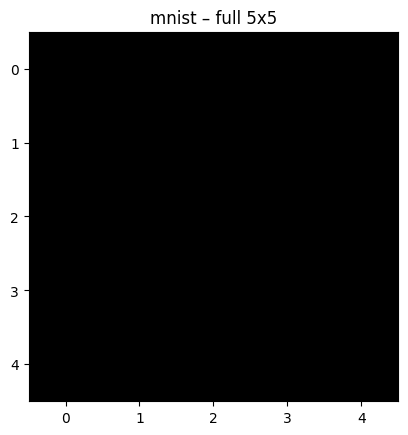

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8934 - loss: 0.3759 - val_accuracy: 0.9603 - val_loss: 0.1385
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9590 - loss: 0.1361 - val_accuracy: 0.9755 - val_loss: 0.0896
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9739 - loss: 0.0894 - val_accuracy: 0.9790 - val_loss: 0.0740
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9807 - loss: 0.0662 - val_accuracy: 0.9815 - val_loss: 0.0647
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9845 - loss: 0.0521 - val_accuracy: 0.9830 - val_loss: 0.0590
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9877 - loss: 0.0423 - val_accuracy: 0.9845 - val_loss: 0.0554
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9901 - loss: 0.0351 - val_accuracy: 0.9853 - val_loss: 0.0539
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9918 - loss: 0.0293 - val_accurac

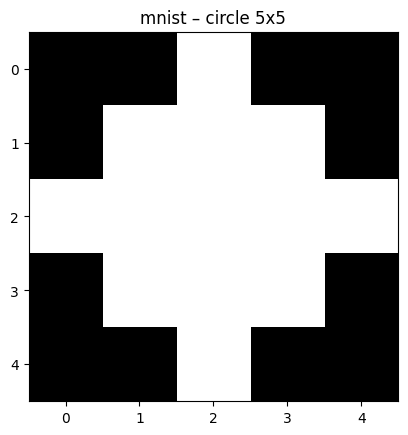

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8845 - loss: 0.4064 - val_accuracy: 0.9543 - val_loss: 0.1588
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9520 - loss: 0.1598 - val_accuracy: 0.9670 - val_loss: 0.1096
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9656 - loss: 0.1125 - val_accuracy: 0.9740 - val_loss: 0.0880
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9735 - loss: 0.0869 - val_accuracy: 0.9773 - val_loss: 0.0765
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9789 - loss: 0.0703 - val_accuracy: 0.9783 - val_loss: 0.0693
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9826 - loss: 0.0581 - val_accuracy: 0.9795 - val_loss: 0.0650
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9859 - loss: 0.0488 - val_accuracy: 0.9807 - val_loss: 0.0617
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9879 - loss: 0.0412 - val_accura

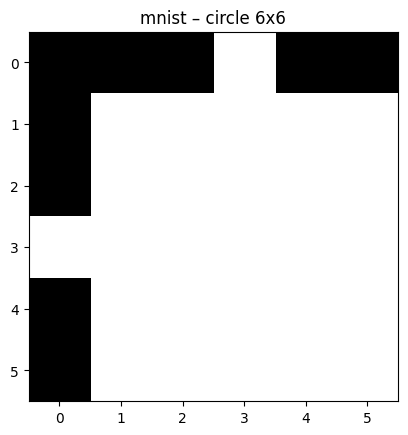

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8874 - loss: 0.3917 - val_accuracy: 0.9555 - val_loss: 0.1516
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9565 - loss: 0.1442 - val_accuracy: 0.9707 - val_loss: 0.0966
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9716 - loss: 0.0956 - val_accuracy: 0.9783 - val_loss: 0.0754
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9791 - loss: 0.0704 - val_accuracy: 0.9813 - val_loss: 0.0660
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9838 - loss: 0.0550 - val_accuracy: 0.9833 - val_loss: 0.0605
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9871 - loss: 0.0444 - val_accuracy: 0.9827 - val_loss: 0.0581
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9895 - loss: 0.0368 - val_accuracy: 0.9833 - val_loss: 0.0568
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9915 - loss: 0.0306 - val_accu

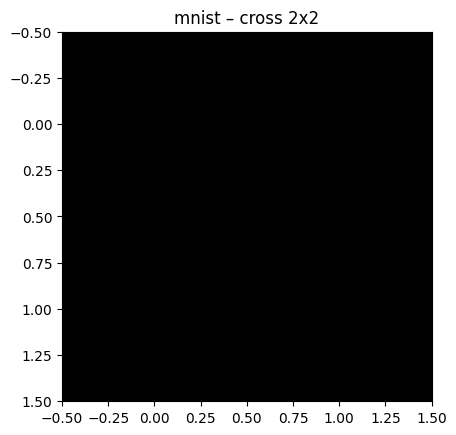

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8804 - loss: 0.4304 - val_accuracy: 0.9500 - val_loss: 0.1741
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9480 - loss: 0.1759 - val_accuracy: 0.9682 - val_loss: 0.1144
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9638 - loss: 0.1218 - val_accuracy: 0.9722 - val_loss: 0.0919
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9722 - loss: 0.0943 - val_accuracy: 0.9772 - val_loss: 0.0808
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9770 - loss: 0.0771 - val_accuracy: 0.9790 - val_loss: 0.0749
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9806 - loss: 0.0649 - val_accuracy: 0.9795 - val_loss: 0.0742
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9833 - loss: 0.0558 - val_accuracy: 0.9790 - val_loss: 0.0726
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9855 - loss: 0.0484 - val_accurac

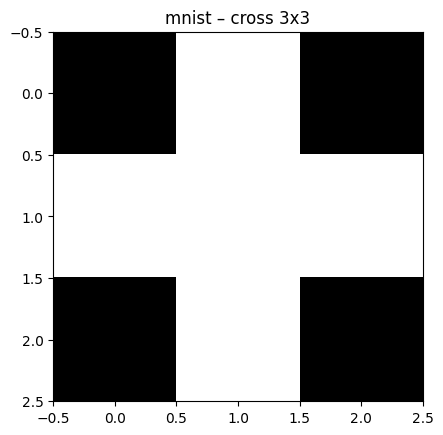

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8765 - loss: 0.4374 - val_accuracy: 0.9503 - val_loss: 0.1699
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9481 - loss: 0.1718 - val_accuracy: 0.9650 - val_loss: 0.1157
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9629 - loss: 0.1221 - val_accuracy: 0.9697 - val_loss: 0.0950
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9717 - loss: 0.0947 - val_accuracy: 0.9745 - val_loss: 0.0824
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9769 - loss: 0.0774 - val_accuracy: 0.9767 - val_loss: 0.0759
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9803 - loss: 0.0654 - val_accuracy: 0.9772 - val_loss: 0.0720
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9832 - loss: 0.0564 - val_accuracy: 0.9788 - val_loss: 0.0705
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9856 - loss: 0.0490 - val_accur

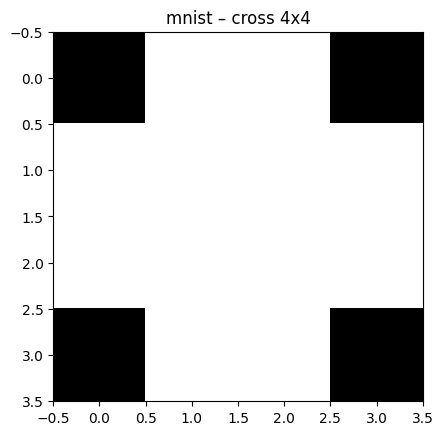

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8957 - loss: 0.3694 - val_accuracy: 0.9540 - val_loss: 0.1571
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9537 - loss: 0.1572 - val_accuracy: 0.9670 - val_loss: 0.1101
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9657 - loss: 0.1156 - val_accuracy: 0.9753 - val_loss: 0.0892
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9727 - loss: 0.0915 - val_accuracy: 0.9762 - val_loss: 0.0792
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9775 - loss: 0.0750 - val_accuracy: 0.9778 - val_loss: 0.0729
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9815 - loss: 0.0632 - val_accuracy: 0.9792 - val_loss: 0.0687
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9841 - loss: 0.0543 - val_accuracy: 0.9807 - val_loss: 0.0641
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9863 - loss: 0.0465 - val_accur

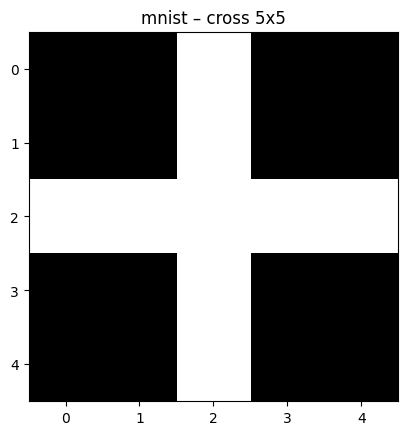

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8732 - loss: 0.4503 - val_accuracy: 0.9500 - val_loss: 0.1740
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9495 - loss: 0.1700 - val_accuracy: 0.9668 - val_loss: 0.1136
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9644 - loss: 0.1186 - val_accuracy: 0.9723 - val_loss: 0.0922
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9735 - loss: 0.0914 - val_accuracy: 0.9755 - val_loss: 0.0818
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9781 - loss: 0.0740 - val_accuracy: 0.9778 - val_loss: 0.0729
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9821 - loss: 0.0614 - val_accuracy: 0.9785 - val_loss: 0.0685
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9853 - loss: 0.0517 - val_accuracy: 0.9797 - val_loss: 0.0658
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9873 - loss: 0.0439 - val_accu

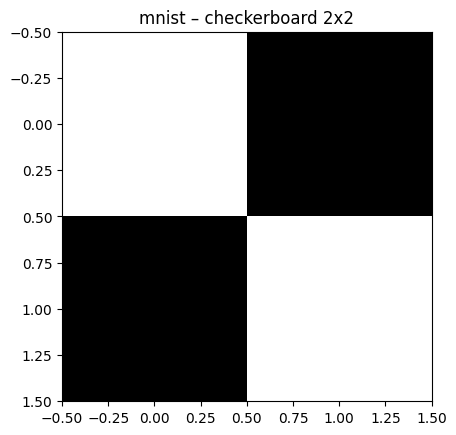

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8635 - loss: 0.4842 - val_accuracy: 0.9435 - val_loss: 0.1921
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9402 - loss: 0.1995 - val_accuracy: 0.9600 - val_loss: 0.1321
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9570 - loss: 0.1440 - val_accuracy: 0.9690 - val_loss: 0.1055
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9659 - loss: 0.1134 - val_accuracy: 0.9732 - val_loss: 0.0916
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9722 - loss: 0.0935 - val_accuracy: 0.9757 - val_loss: 0.0841
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9761 - loss: 0.0789 - val_accuracy: 0.9777 - val_loss: 0.0792
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9794 - loss: 0.0677 - val_accuracy: 0.9792 - val_loss: 0.0764
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9824 - loss: 0.0585 - val_accu

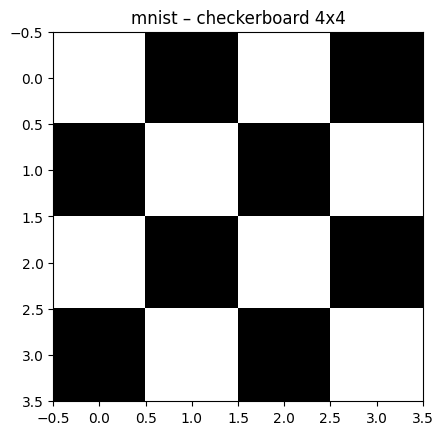

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8759 - loss: 0.4414 - val_accuracy: 0.9507 - val_loss: 0.1681
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9484 - loss: 0.1723 - val_accuracy: 0.9655 - val_loss: 0.1175
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9630 - loss: 0.1234 - val_accuracy: 0.9735 - val_loss: 0.0930
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9716 - loss: 0.0956 - val_accuracy: 0.9782 - val_loss: 0.0793
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9771 - loss: 0.0776 - val_accuracy: 0.9795 - val_loss: 0.0721
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9813 - loss: 0.0645 - val_accuracy: 0.9802 - val_loss: 0.0682
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9838 - loss: 0.0547 - val_accuracy: 0.9808 - val_loss: 0.0657
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9863 - loss: 0.0469 - val_accu

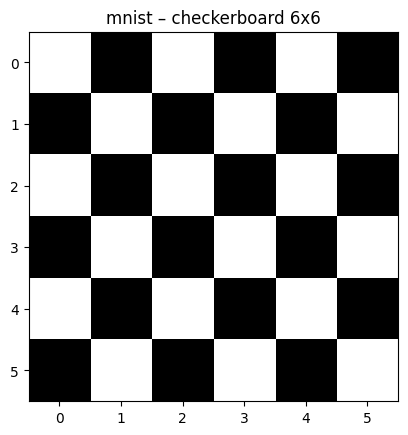

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8894 - loss: 0.4072 - val_accuracy: 0.9583 - val_loss: 0.1538
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9545 - loss: 0.1538 - val_accuracy: 0.9705 - val_loss: 0.1006
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9700 - loss: 0.1037 - val_accuracy: 0.9768 - val_loss: 0.0820
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9777 - loss: 0.0779 - val_accuracy: 0.9788 - val_loss: 0.0724
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9820 - loss: 0.0619 - val_accuracy: 0.9803 - val_loss: 0.0655
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9849 - loss: 0.0511 - val_accuracy: 0.9820 - val_loss: 0.0609
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9873 - loss: 0.0430 - val_accuracy: 0.9835 - val_loss: 0.0578
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9893 - loss: 0.0367 - val_accu

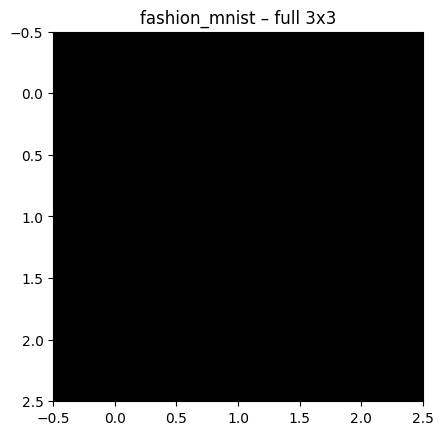

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7995 - loss: 0.5736 - val_accuracy: 0.8533 - val_loss: 0.4175
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8653 - loss: 0.3829 - val_accuracy: 0.8697 - val_loss: 0.3614
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8804 - loss: 0.3367 - val_accuracy: 0.8795 - val_loss: 0.3320
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8899 - loss: 0.3073 - val_accuracy: 0.8860 - val_loss: 0.3091
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8976 - loss: 0.2847 - val_accuracy: 0.8922 - val_loss: 0.2933
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9042 - loss: 0.2666 - val_accuracy: 0.8970 - val_loss: 0.2829
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9100 - loss: 0.2508 - val_accuracy: 0.9002 - val_loss: 0.2739
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9149 - loss: 0.2364 - val_accu

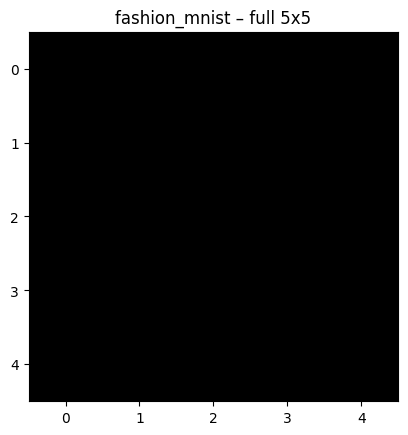

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7964 - loss: 0.5804 - val_accuracy: 0.8508 - val_loss: 0.4232
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8669 - loss: 0.3799 - val_accuracy: 0.8707 - val_loss: 0.3648
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8823 - loss: 0.3304 - val_accuracy: 0.8778 - val_loss: 0.3324
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8914 - loss: 0.2990 - val_accuracy: 0.8890 - val_loss: 0.3103
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9004 - loss: 0.2750 - val_accuracy: 0.8943 - val_loss: 0.2954
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9068 - loss: 0.2556 - val_accuracy: 0.8985 - val_loss: 0.2833
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9140 - loss: 0.2383 - val_accuracy: 0.9020 - val_loss: 0.2731
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9198 - loss: 0.2229 - val_accu

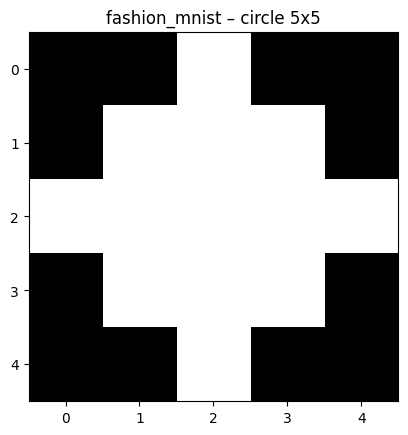

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7890 - loss: 0.6034 - val_accuracy: 0.8438 - val_loss: 0.4376
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8608 - loss: 0.3915 - val_accuracy: 0.8662 - val_loss: 0.3737
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8776 - loss: 0.3413 - val_accuracy: 0.8785 - val_loss: 0.3364
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8884 - loss: 0.3106 - val_accuracy: 0.8888 - val_loss: 0.3103
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8974 - loss: 0.2867 - val_accuracy: 0.8940 - val_loss: 0.2933
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9043 - loss: 0.2669 - val_accuracy: 0.8975 - val_loss: 0.2810
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9106 - loss: 0.2492 - val_accuracy: 0.9022 - val_loss: 0.2715
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9172 - loss: 0.2333 - val_accu

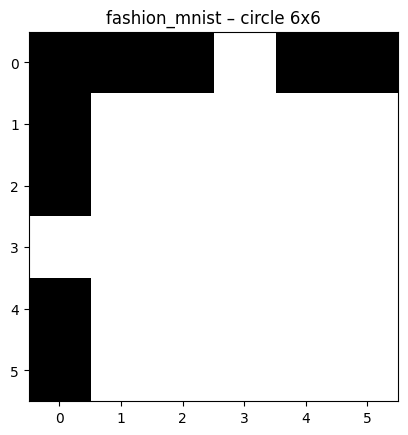

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7940 - loss: 0.5882 - val_accuracy: 0.8500 - val_loss: 0.4239
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8646 - loss: 0.3822 - val_accuracy: 0.8697 - val_loss: 0.3610
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8814 - loss: 0.3331 - val_accuracy: 0.8797 - val_loss: 0.3279
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8909 - loss: 0.3012 - val_accuracy: 0.8882 - val_loss: 0.3064
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8990 - loss: 0.2769 - val_accuracy: 0.8930 - val_loss: 0.2914
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9064 - loss: 0.2569 - val_accuracy: 0.8977 - val_loss: 0.2804
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9134 - loss: 0.2395 - val_accuracy: 0.8997 - val_loss: 0.2721
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9195 - loss: 0.2243 - val_accu

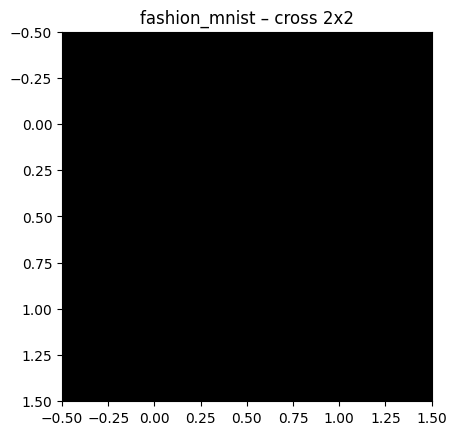

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7981 - loss: 0.5793 - val_accuracy: 0.8527 - val_loss: 0.4184
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8641 - loss: 0.3861 - val_accuracy: 0.8648 - val_loss: 0.3698
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8793 - loss: 0.3417 - val_accuracy: 0.8740 - val_loss: 0.3425
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8884 - loss: 0.3141 - val_accuracy: 0.8793 - val_loss: 0.3226
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8942 - loss: 0.2937 - val_accuracy: 0.8880 - val_loss: 0.3097
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8999 - loss: 0.2768 - val_accuracy: 0.8918 - val_loss: 0.2983
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9050 - loss: 0.2620 - val_accuracy: 0.8938 - val_loss: 0.2889
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9101 - loss: 0.2489 - val_accur

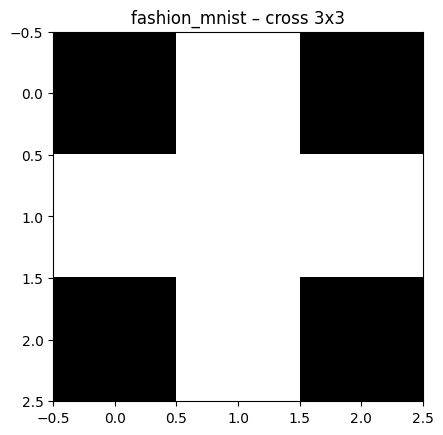

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7972 - loss: 0.5896 - val_accuracy: 0.8528 - val_loss: 0.4151
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8631 - loss: 0.3882 - val_accuracy: 0.8665 - val_loss: 0.3690
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8777 - loss: 0.3426 - val_accuracy: 0.8778 - val_loss: 0.3412
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8867 - loss: 0.3151 - val_accuracy: 0.8833 - val_loss: 0.3236
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8933 - loss: 0.2945 - val_accuracy: 0.8877 - val_loss: 0.3093
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8995 - loss: 0.2774 - val_accuracy: 0.8888 - val_loss: 0.2979
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9049 - loss: 0.2623 - val_accuracy: 0.8937 - val_loss: 0.2899
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9106 - loss: 0.2487 - val_accu

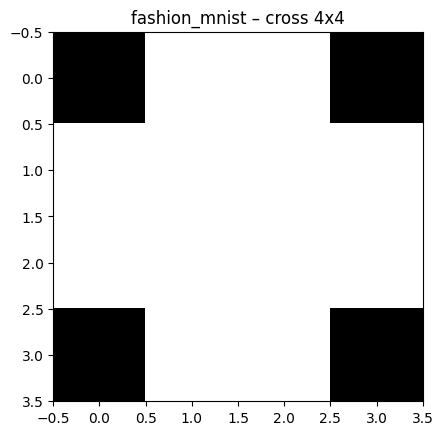

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7899 - loss: 0.6009 - val_accuracy: 0.8468 - val_loss: 0.4301
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8620 - loss: 0.3900 - val_accuracy: 0.8695 - val_loss: 0.3687
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8789 - loss: 0.3408 - val_accuracy: 0.8792 - val_loss: 0.3339
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8891 - loss: 0.3097 - val_accuracy: 0.8847 - val_loss: 0.3106
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8970 - loss: 0.2865 - val_accuracy: 0.8937 - val_loss: 0.2952
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9036 - loss: 0.2672 - val_accuracy: 0.8993 - val_loss: 0.2839
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9095 - loss: 0.2508 - val_accuracy: 0.9010 - val_loss: 0.2755
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9155 - loss: 0.2357 - val_accura

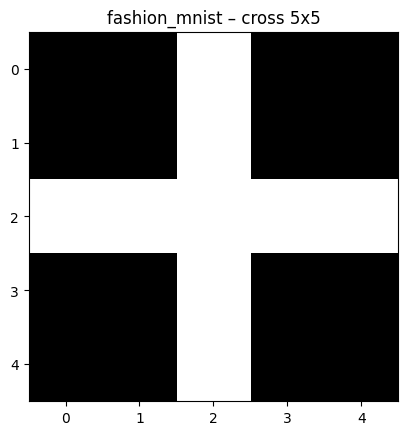

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7868 - loss: 0.6108 - val_accuracy: 0.8470 - val_loss: 0.4277
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8604 - loss: 0.3950 - val_accuracy: 0.8697 - val_loss: 0.3732
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8754 - loss: 0.3490 - val_accuracy: 0.8745 - val_loss: 0.3481
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8844 - loss: 0.3212 - val_accuracy: 0.8807 - val_loss: 0.3268
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8912 - loss: 0.2996 - val_accuracy: 0.8870 - val_loss: 0.3099
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8971 - loss: 0.2818 - val_accuracy: 0.8922 - val_loss: 0.2971
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9030 - loss: 0.2666 - val_accuracy: 0.8957 - val_loss: 0.2875
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9082 - loss: 0.2530 - val_accu

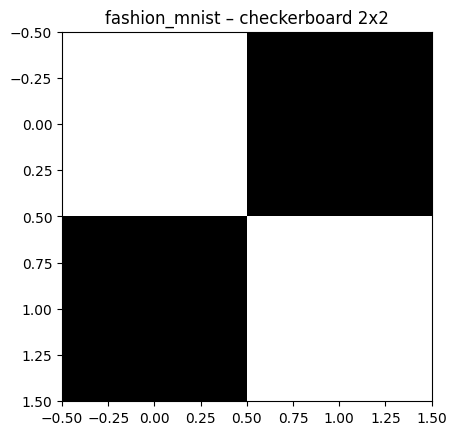

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7902 - loss: 0.6159 - val_accuracy: 0.8462 - val_loss: 0.4327
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8595 - loss: 0.4000 - val_accuracy: 0.8617 - val_loss: 0.3868
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8750 - loss: 0.3551 - val_accuracy: 0.8697 - val_loss: 0.3598
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8838 - loss: 0.3275 - val_accuracy: 0.8783 - val_loss: 0.3401
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8903 - loss: 0.3075 - val_accuracy: 0.8835 - val_loss: 0.3270
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8957 - loss: 0.2910 - val_accuracy: 0.8872 - val_loss: 0.3150
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9003 - loss: 0.2774 - val_accuracy: 0.8905 - val_loss: 0.3066
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9048 - loss: 0.2648 - val_accu

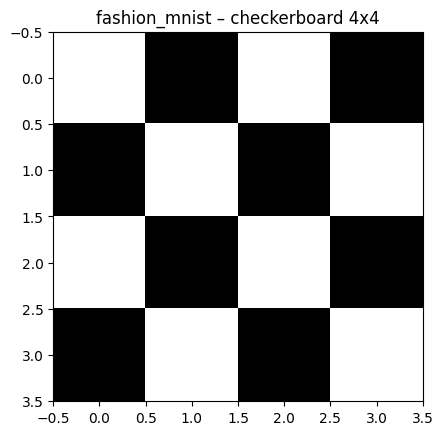

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7847 - loss: 0.6278 - val_accuracy: 0.8453 - val_loss: 0.4383
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8593 - loss: 0.3996 - val_accuracy: 0.8642 - val_loss: 0.3826
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8764 - loss: 0.3498 - val_accuracy: 0.8752 - val_loss: 0.3466
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8857 - loss: 0.3190 - val_accuracy: 0.8840 - val_loss: 0.3218
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8931 - loss: 0.2963 - val_accuracy: 0.8888 - val_loss: 0.3046
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8996 - loss: 0.2772 - val_accuracy: 0.8928 - val_loss: 0.2931
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9053 - loss: 0.2610 - val_accuracy: 0.8977 - val_loss: 0.2839
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9115 - loss: 0.2460 - val_accu

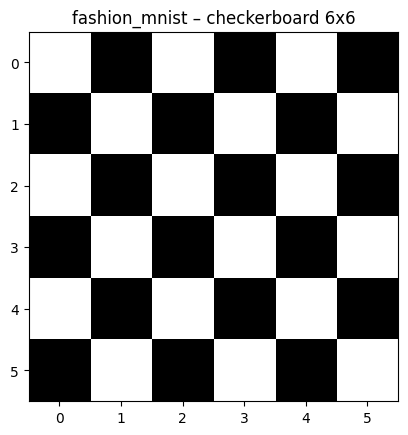

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7799 - loss: 0.6320 - val_accuracy: 0.8417 - val_loss: 0.4468
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8583 - loss: 0.4045 - val_accuracy: 0.8625 - val_loss: 0.3854
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8756 - loss: 0.3540 - val_accuracy: 0.8715 - val_loss: 0.3500
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8852 - loss: 0.3222 - val_accuracy: 0.8802 - val_loss: 0.3275
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8928 - loss: 0.2980 - val_accuracy: 0.8888 - val_loss: 0.3105
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8995 - loss: 0.2780 - val_accuracy: 0.8902 - val_loss: 0.2997
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9061 - loss: 0.2604 - val_accuracy: 0.8933 - val_loss: 0.2912
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9118 - loss: 0.2451 - val_accu

In [20]:
datasets = ['mnist', 'fashion_mnist']
all_results = []

for ds_name in datasets:
    print(f"\n{'='*60}")
    print(f"Запуск на датасете: {ds_name.upper()}")
    print('='*60)

    x_train, y_train, x_test, y_test, input_shape, num_classes = load_dataset(ds_name)

    epochs = 10
    batch_size = 128

    for exp_name, exp_data in experiments.items():
        for size in exp_data['sizes']:
            print(f"\n--- {exp_name}, размер {size}x{size} ---")
            mask = exp_data['mask_fn'](size)
            
            plt.imshow(mask, cmap='gray')
            plt.title(f'{ds_name} – {exp_name} {size}x{size}')
            plt.show()

            optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
            model =  build_model(input_shape, mask, size, num_classes=num_classes)
            model.compile(optimizer=optimizer,
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

            early_stop = tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=3, restore_best_weights=True
            )

            history = model.fit(x_train, y_train,
                                epochs=epochs,
                                batch_size=batch_size,
                                validation_split=0.1,
                                callbacks=[early_stop],
                                verbose=1)

            test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
            all_results.append({
                'dataset': ds_name,
                'filter_type': exp_name,
                'size': size,
                'test_accuracy': test_acc,
                'params': model.count_params()
            })
            print(f"Test accuracy: {test_acc:.4f}")


Полная таблица результатов:
          dataset   filter_type  size  test_accuracy  params
12  fashion_mnist          full     5         0.9031  805066
14  fashion_mnist        circle     6         0.9008  805418
11  fashion_mnist          full     3         0.8998  804554
13  fashion_mnist        circle     5         0.8992  805066
20  fashion_mnist  checkerboard     4         0.8986  804778
18  fashion_mnist         cross     5         0.8982  805066
16  fashion_mnist         cross     3         0.8980  804554
17  fashion_mnist         cross     4         0.8979  804778
21  fashion_mnist  checkerboard     6         0.8978  805418
15  fashion_mnist         cross     2         0.8962  804394
19  fashion_mnist  checkerboard     2         0.8906  804394
10          mnist  checkerboard     6         0.9850  805418
3           mnist        circle     6         0.9848  805418
1           mnist          full     5         0.9844  805066
9           mnist  checkerboard     4         0.9826  80

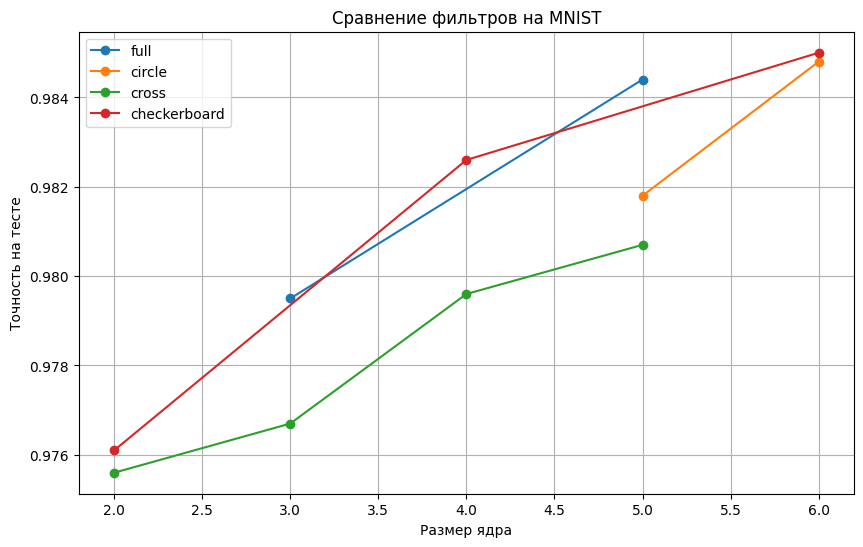

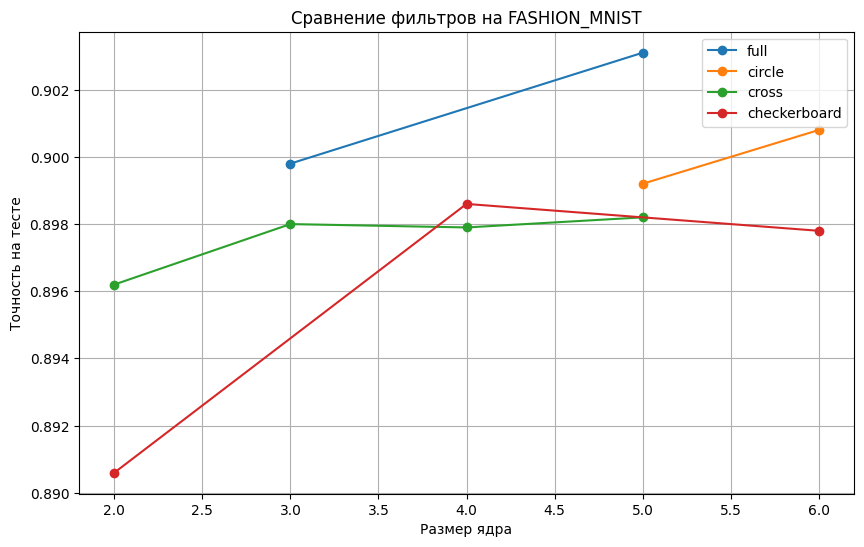


Лучшие результаты по датасетам:
          dataset   filter_type  size  test_accuracy
12  fashion_mnist          full     5         0.9031
10          mnist  checkerboard     6         0.9850


In [21]:
df = pd.DataFrame(all_results)
print("\nПолная таблица результатов:")
print(df.sort_values(['dataset', 'test_accuracy'], ascending=[True, False]))

# Графики по каждому датасету отдельно
for ds_name in datasets:
    df_ds = df[df['dataset'] == ds_name]
    plt.figure(figsize=(10, 6))
    for ft in df_ds['filter_type'].unique():
        sub = df_ds[df_ds['filter_type'] == ft]
        plt.plot(sub['size'], sub['test_accuracy'], marker='o', label=ft)
    plt.xlabel('Размер ядра')
    plt.ylabel('Точность на тесте')
    plt.title(f'Сравнение фильтров на {ds_name.upper()}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Сводный график: сравнение лучших результатов по каждому датасету
best_per_dataset = df.loc[df.groupby('dataset')['test_accuracy'].idxmax()]
print("\nЛучшие результаты по датасетам:")
print(best_per_dataset[['dataset', 'filter_type', 'size', 'test_accuracy']])

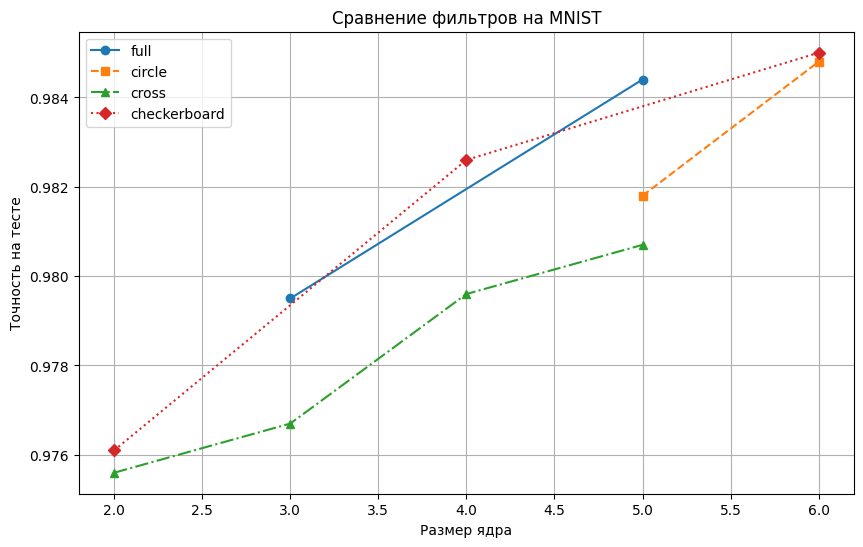

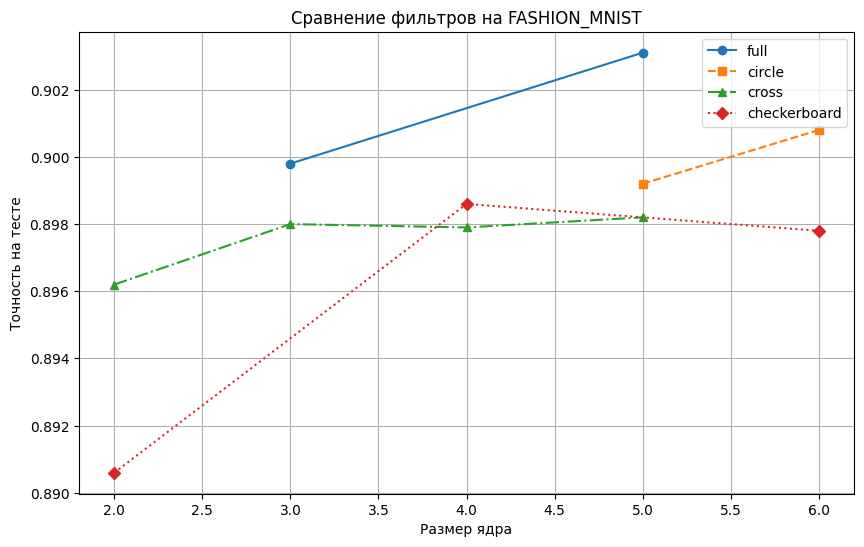

In [22]:
import matplotlib.pyplot as plt

# Словарь стилей линий для каждого типа фильтра
linestyles = {
    'full': '-',          # сплошная
    'circle': '--',       # пунктирная
    'cross': '-.',        # штрих-пунктирная
    'checkerboard': ':'   # точки
}

# Словарь маркеров (опционально, чтобы ещё сильнее различать)
markers = {
    'full': 'o',
    'circle': 's',
    'cross': '^',
    'checkerboard': 'D'
}

# Графики по каждому датасету отдельно
for ds_name in datasets:
    df_ds = df[df['dataset'] == ds_name]
    plt.figure(figsize=(10, 6))
    for ft in df_ds['filter_type'].unique():
        sub = df_ds[df_ds['filter_type'] == ft]
        plt.plot(sub['size'], sub['test_accuracy'],
                 marker=markers.get(ft, 'o'),   # маркер по умолчанию 'o'
                 linestyle=linestyles.get(ft, '-'),  # стиль по умолчанию сплошной
                 label=ft)
    plt.xlabel('Размер ядра')
    plt.ylabel('Точность на тесте')
    plt.title(f'Сравнение фильтров на {ds_name.upper()}')
    plt.legend()
    plt.grid(True)
    plt.show()